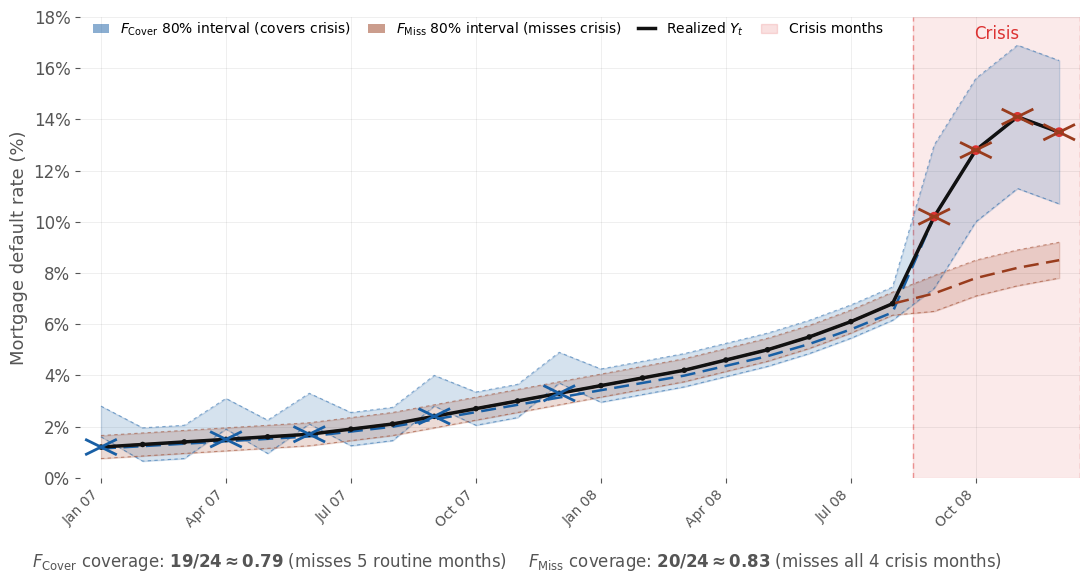

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Data ──────────────────────────────────────────────────────────────────────
months = [
    'Jan 07','Feb 07','Mar 07','Apr 07','May 07','Jun 07',
    'Jul 07','Aug 07','Sep 07','Oct 07','Nov 07','Dec 07',
    'Jan 08','Feb 08','Mar 08','Apr 08','May 08','Jun 08',
    'Jul 08','Aug 08','Sep 08','Oct 08','Nov 08','Dec 08'
]
t = np.arange(len(months))

realized = np.array([
    1.2, 1.3, 1.4, 1.5, 1.6, 1.7,
    1.9, 2.1, 2.4, 2.7, 3.0, 3.3,
    3.6, 3.9, 4.2, 4.6, 5.0, 5.5,
    6.1, 6.8, 10.2, 12.8, 14.1, 13.5
])

crisis_idx   = [20, 21, 22, 23]
fhat_miss    = [0, 3, 5, 8, 11]   # routine months F-hat misses
ftilde_miss  = crisis_idx          # crisis months F-tilde misses

# ── F-hat bands (blue) ────────────────────────────────────────────────────────
fh_lo = np.where(
    np.isin(t, crisis_idx), realized - 2.8,
    np.where(np.isin(t, fhat_miss), realized + 0.4, realized - 0.65)
)
fh_hi = np.where(
    np.isin(t, crisis_idx), realized + 2.8,
    np.where(np.isin(t, fhat_miss), realized + 1.6, realized + 0.65)
)
fh_med = np.where(np.isin(t, crisis_idx), realized, realized * 0.95)

# ── F-tilde bands (red) ───────────────────────────────────────────────────────
ft_med = realized.copy().astype(float)
for offset, val in enumerate([7.2, 7.8, 8.2, 8.5]):
    ft_med[20 + offset] = val

ft_lo = np.where(np.isin(t, crisis_idx), ft_med - 0.7, ft_med - 0.45)
ft_hi = np.where(np.isin(t, crisis_idx), ft_med + 0.7, ft_med + 0.45)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5.5), facecolor='white')
ax.set_facecolor('white')

BLUE   = '#185FA5'
RED    = '#993C1D'
BLUE_A = (*plt.matplotlib.colors.to_rgb(BLUE), 0.18)
RED_A  = (*plt.matplotlib.colors.to_rgb(RED),  0.18)

# Crisis shading
ax.axvspan(19.5, 23.5, color='#DC3232', alpha=0.10, zorder=0)
for x in [19.5, 23.5]:
    ax.axvline(x, color='#DC3232', alpha=0.45, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
ax.text(21.5, 17.7, 'Crisis', color='#DC3232', fontsize=12, ha='center', va='top', fontweight='500')

# F-hat confidence band
ax.fill_between(t, fh_lo, fh_hi, color=BLUE, alpha=0.18, zorder=2)
ax.plot(t, fh_lo, color=BLUE, alpha=0.5, linewidth=0.8, linestyle=(0, (3, 3)), zorder=3)
ax.plot(t, fh_hi, color=BLUE, alpha=0.5, linewidth=0.8, linestyle=(0, (3, 3)), zorder=3)
ax.plot(t, fh_med, color=BLUE, linewidth=1.8, linestyle=(0, (6, 3)), zorder=4)

# F-tilde confidence band
ax.fill_between(t, ft_lo, ft_hi, color=RED, alpha=0.18, zorder=2)
ax.plot(t, ft_lo, color=RED, alpha=0.5, linewidth=0.8, linestyle=(0, (3, 3)), zorder=3)
ax.plot(t, ft_hi, color=RED, alpha=0.5, linewidth=0.8, linestyle=(0, (3, 3)), zorder=3)
ax.plot(t, ft_med, color=RED, linewidth=1.8, linestyle=(0, (6, 3)), zorder=4)

# Realized line
point_colors = ['#DC3232' if i in crisis_idx else '#111111' for i in t]
point_sizes  = [7 if i in crisis_idx else 4 for i in t]
ax.plot(t, realized, color='#111111', linewidth=2.5, zorder=6)
ax.scatter(t, realized, c=point_colors, s=[s**2 for s in point_sizes],
           zorder=7, edgecolors='none')

# Miss crosses
def draw_cross(ax, i, color, size=0.35):
    x, y = t[i], realized[i]
    ax.plot([x - size, x + size], [y - size * 0.8, y + size * 0.8],
            color=color, linewidth=2, zorder=8)
    ax.plot([x + size, x - size], [y - size * 0.8, y + size * 0.8],
            color=color, linewidth=2, zorder=8)

for i in fhat_miss:
    draw_cross(ax, i, BLUE)
for i in ftilde_miss:
    draw_cross(ax, i, RED)

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_xlim(-0.5, 23.5)
ax.set_ylim(0, 18)
ax.set_xticks(t[::3])
ax.set_xticklabels([months[i] for i in t[::3]], rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(0, 19, 2))
ax.set_yticklabels([f'{v}%' for v in range(0, 19, 2)], fontsize=12)
ax.set_ylabel('Mortgage default rate (%)', fontsize=13, color='#555')
ax.tick_params(colors='#555')
ax.grid(color='#111111', alpha=0.08, linewidth=0.6)
for spine in ax.spines.values():
    spine.set_visible(False)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor=BLUE, alpha=0.5, label='$F_{\\text{Cover}}$ 80% interval (covers crisis)'),
    mpatches.Patch(facecolor=RED,  alpha=0.5, label='$F_{\\text{Miss}}$ 80% interval (misses crisis)'),
    Line2D([0], [0], color='#111111', linewidth=2.5, label='Realized $Y_t$'),
    mpatches.Patch(facecolor='#DC3232', alpha=0.15,
                   edgecolor='#DC3232', label='Crisis months'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10,
          frameon=False, ncol=4, bbox_to_anchor=(0.0, 1.02),
          columnspacing=1.2, handlelength=1.2)

# ── Footer annotation ─────────────────────────────────────────────────────────
fig.text(0.25, -0.04,
         '$F_{\\text{Cover}}$ coverage: $\\mathbf{19/24 \\approx 0.79}$ (misses 5 routine months)',
         ha='center', fontsize=12, color='#555')
fig.text(0.70, -0.04,
         '$F_{\\text{Miss}}$ coverage: $\\mathbf{20/24 \\approx 0.83}$ (misses all 4 crisis months)',
         ha='center', fontsize=12, color='#555')

plt.tight_layout()
plt.savefig('mortgage_default_coverage.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

In [2]:
import pyarrow.dataset as ds
import pyarrow.fs as fs
import pyarrow.compute as pc
import pyarrow as pa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def uniquely_identified(df:pd.DataFrame, by:list[str]) -> bool:
    return df.duplicated(subset=by).sum() == 0

s3 = fs.S3FileSystem(anonymous=True)
target_forecasters = ["CMU-TimeSeries", "FluSight-ensemble", "FluSight-lop_norm", "UMass-flusion"]
target_series = ['wk inc flu hosp', 'wk inc flu prop ed visits']


mo = ds.dataset(
    "cdcepi-flusight-forecast-hub/model-output/",
    filesystem=s3,
    format="parquet"
)

with s3.open_input_file("cdcepi-flusight-forecast-hub/target-data/time-series.csv") as f:
    time_series = pd.read_csv(f)

oracle_asof = time_series.loc[
    time_series["target"].isin(target_series) 
].copy()
oracle_asof[["target_end_date", "as_of"]] = oracle_asof[["target_end_date", "as_of"]].apply(pd.to_datetime)

with s3.open_input_file("cdcepi-flusight-forecast-hub/target-data/oracle-output.csv") as f:
    oracle = pd.read_csv(f)

forecasts = mo.to_table(
    filter=(
        (pc.field("target").isin(target_series)) &
        (pc.field("output_type") == "quantile")  & 
        (pc.field("horizon") >= 0) &
        (pc.field("model_id").isin(target_forecasters))
    )
).to_pandas()
forecasts[["target_end_date", "reference_date"]] = forecasts[["target_end_date", "reference_date"]].apply(pd.to_datetime)

assert uniquely_identified(forecasts, by=["target", "target_end_date", "location", "horizon", "model_id", "output_type_id"])

In [3]:
DROP_FORECAST_COLS = ['round_id', 'output_type']
DROP_ORACLE_COLS = ['as_of', 'weekly_rate']

def widen(forecast_df: pd.DataFrame) -> pd.DataFrame:
    forecasts_wide = forecast_df.pivot_table(
        index=[c for c in forecast_df.columns if c not in ["output_type", "output_type_id", "value"]],
        columns="output_type_id",
        values="value"
    ).reset_index()
    forecasts_wide.columns.name = None
    new_quantile_cols = [c for c in forecasts_wide.columns if c not in forecast_df.columns]
    forecasts_wide = forecasts_wide.rename(columns={c: f"quantile_{c}" for c in new_quantile_cols})
    return forecasts_wide

def filter_dates(oracle_df: pd.DataFrame, date_ranges: dict[tuple[str, str], str]) -> pd.DataFrame:
    """
    date_ranges: { (start, end): asof, ... }
    e.g. { ("2023-10-01", "2024-05-01"): "2024-05-15",
           ("2024-10-01", "2025-05-01"): "2025-05-15" }
    """
    masks = []
    for (start, end), asof in date_ranges.items():
        mask = (
            (oracle_df["target_end_date"] >= pd.Timestamp(start)) &
            (oracle_df["target_end_date"] <= pd.Timestamp(end)) &
            (oracle_df["as_of"] == pd.Timestamp(asof))
        )
        masks.append(mask)

    combined = pd.concat([oracle_df[m] for m in masks], ignore_index=True)
    return combined

def drop_redundant_cols(merged_df:pd.DataFrame) -> pd.DataFrame:
    return merged_df.drop(columns=DROP_FORECAST_COLS + DROP_ORACLE_COLS)

def merge_and_process(forecasts:pd.DataFrame, oracle:pd.DataFrame) -> pd.DataFrame:
    assert uniquely_identified(oracle, by=["target", "target_end_date", "location"])
    assert uniquely_identified(forecasts, by=["target", "target_end_date", "location", "horizon", "model_id", "output_type_id"])
    merged = forecasts.merge(oracle, on=["target", "target_end_date", "location"], how="left")
    merged = drop_redundant_cols(merged)
    merged_wide = widen(merged)
    return merged_wide

def define_id(result_df: pd.DataFrame, id_cols: list[str]) -> pd.DataFrame:
    result_df["id"] = result_df[id_cols].astype(str).agg("|".join, axis=1)
    return result_df[["id"] + [c for c in result_df.columns if c != "id"]]

def build_evaluation_df(forecasts:pd.DataFrame, 
                        oracle:pd.DataFrame, 
                        date_ranges: dict[tuple[str, str], str],
                        id_cols = ["target", "reference_date", "location", "horizon", "model_id"]) ->pd.DataFrame:
    filtered_oracle = filter_dates(oracle, date_ranges)
    evaluation_df = merge_and_process(forecasts, filtered_oracle)
    assert uniquely_identified(evaluation_df, by=id_cols)
    evaluation_df = define_id(evaluation_df, id_cols)
    return evaluation_df

def build_evaluation_dict(
    forecasts: pd.DataFrame,
    oracle: pd.DataFrame,
    date_ranges: dict[tuple[str, str], str],
    model_id: list[str] = ['FluSight-ensemble'],
) -> dict[str, pd.DataFrame]:
    df = build_evaluation_df(forecasts, oracle, date_ranges)
    return {mid: df[df["model_id"] == mid].reset_index(drop=True) for mid in model_id}

date_ranges = {
    ("2023-10-14", "2024-04-27"): "2024-04-27",
    ("2024-10-14", "2025-06-21"): "2025-07-23"
}

result = build_evaluation_df(forecasts, oracle_asof, date_ranges)
assert uniquely_identified(result, by=["target", "reference_date", "location", "horizon", "model_id"])

First step in the data processing pipeline is merging the forecasts and oracle series

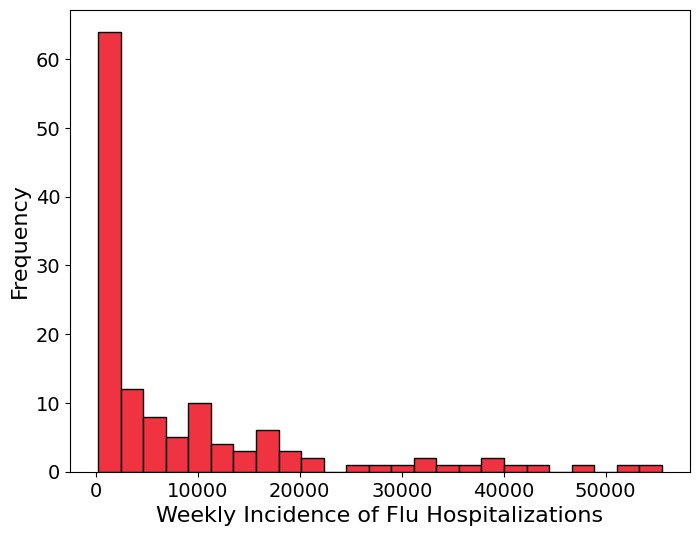

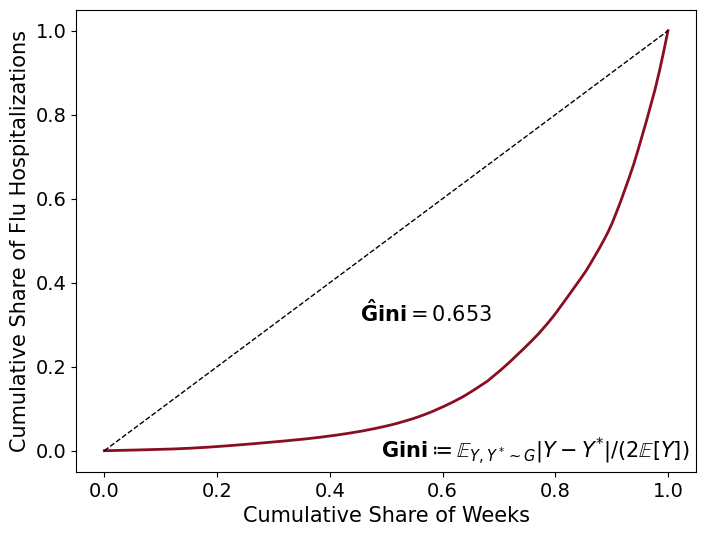

In [38]:
oracle_mask = (oracle['target'] == 'wk inc flu hosp') & (oracle['location'] == 'US') & (oracle['horizon'] == 0)
# question: is it not log-normal?

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(oracle[oracle_mask]["oracle_value"], edgecolor='black', color='#EF3340', bins=25)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel('Weekly Incidence of Flu Hospitalizations', size=16)
ax.set_ylabel('Frequency', size=16)
plt.savefig("histogram.png", dpi=300, bbox_inches='tight')
plt.show()

data = oracle[oracle_mask].sort_values("oracle_value")["oracle_value"].values
lorenz = np.cumsum(data) / data.sum() #type:ignore
lorenz = np.insert(lorenz, 0, 0)  # start at (0,0)
x = np.linspace(0, 1, len(lorenz))

n = len(data)
G = (2 * np.sum(np.arange(1, n+1) * data)) / (n * data.sum()) - (n + 1) / n #type:ignore

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, lorenz, color='#8B0D21', linewidth=2)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.plot([0, 1], [0, 1], color='black', linewidth=1, linestyle='--')  # equality line
ax.set_xlabel('Cumulative Share of Weeks', size=15)
ax.set_ylabel('Cumulative Share of Flu Hospitalizations', size=15)
ax.text(0.57, 0.33, r'$\mathbf{\hat{G}ini} = $' + f'{G:.3f}',
        fontsize=15, ha='center', va='center', color='black')
ax.text(0.765, 0, r'$\mathbf{Gini} \coloneq \mathbb{E}_{Y, Y^* \sim G}|Y-Y^{*}|/(2\mathbb{E}[Y])$',
        fontsize=15, ha='center', va='center', color='black')
plt.savefig("lorenz.png", dpi=300, bbox_inches='tight')
plt.show()

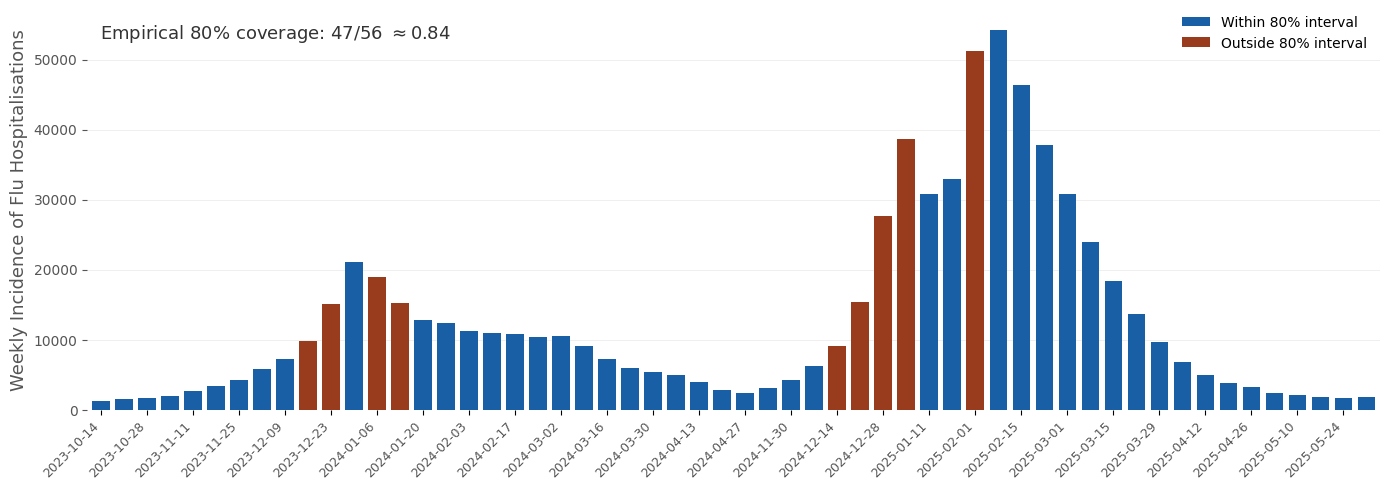

In [72]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ── Filter (your existing code) ───────────────────────────────────────────────
result_mask = (
    (result['target']   == 'wk inc flu hosp') &
    (result['location'] == 'US') &
    (result['horizon']  == 0) &
    (result['model_id'] == 'FluSight-ensemble')
)
result_filtered = result[result_mask].copy()
result_filtered['cover_80'] = (
    (result_filtered['observation'] >= result_filtered['quantile_0.1']) &
    (result_filtered['observation'] <= result_filtered['quantile_0.9'])
)

# ── Sort by date if you have one (adjust column name as needed) ───────────────
date_col = 'reference_date'   # <-- change if your date column has a different name
if date_col in result_filtered.columns:
    result_filtered = result_filtered.sort_values(date_col)
    labels = result_filtered[date_col].astype(str).tolist()
else:
    labels = list(range(len(result_filtered)))

observations = result_filtered['observation'].tolist()
covered      = result_filtered['cover_80'].tolist()

# ── Colors ────────────────────────────────────────────────────────────────────
COLOR_HIT  = '#185FA5'   # blue  — covered
COLOR_MISS = '#993C1D'   # coral — not covered

bar_colors = [COLOR_HIT if c else COLOR_MISS for c in covered]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5), facecolor='white')
ax.set_facecolor('white')

bars = ax.bar(range(len(observations)), observations, color=bar_colors,
              width=0.75, zorder=2)

# ── Axes formatting ───────────────────────────────────────────────────────────
tick_every = max(1, len(labels) // 20)   # show ~20 labels max
ax.set_xticks(range(0, len(labels), tick_every))
ax.set_xticklabels(
    [labels[i] for i in range(0, len(labels), tick_every)],
    rotation=45, ha='right', fontsize=9, color='#555'
)
ax.set_ylabel('Weekly Incidence of Flu Hospitalisations', fontsize=13, color='#555')
ax.tick_params(axis='y', colors='#555')
ax.grid(axis='y', color='#111111', alpha=0.08, linewidth=0.6, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xlim(-0.6, len(observations) - 0.4)

# ── Coverage rate annotation ──────────────────────────────────────────────────
n_covered = sum(covered)
n_total   = len(covered)
rate      = n_covered / n_total
ax.text(0.01, 0.97,
        f'Empirical 80% coverage: {n_covered}/{n_total} $\\approx {rate:.2f}$',
        transform=ax.transAxes, fontsize=13, color='#333',
        va='top', ha='left')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(facecolor=COLOR_HIT,  label='Within 80% interval'),
    mpatches.Patch(facecolor=COLOR_MISS, label='Outside 80% interval'),
]
ax.legend(handles=legend_handles, fontsize=10, frameon=False,
          loc='upper right', bbox_to_anchor=(1.0, 1.02))

plt.tight_layout()
plt.savefig('flu_coverage_bar.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [531]:
import numpy as np
import pandas as pd
from typing import Callable, Optional

def assert_percentile(p: int):
    if 0 <= p <= 100:
        return p
    raise ValueError(f"Percentile {p} is out of range. Must be between 0 and 100.")

def percentile_value(df: pd.DataFrame, oracle_col: str, p: int) -> float:
    """p in [0, 100], e.g. p=90 for 90th percentile"""
    return df[oracle_col].quantile(assert_percentile(p) / 100)

def compute_cdf_value(row: pd.Series, x: float, quantile_cols: list[str], quantile_levels: list[float]) -> float:
    values = np.asarray(row[quantile_cols], dtype=np.float64)
    levels = np.asarray(quantile_levels, dtype=np.float64)
    assert np.all(np.diff(values) >= 0), f"Quantile crossing detected: {values}"
    assert np.all(np.diff(levels) > 0), f"Quantile levels must be increasing: {quantile_levels}"
    return float(np.interp(x, values, levels))

def parse_quantile_cols(df: pd.DataFrame, prefix: str = "quantile_") -> tuple[list[str], list[float]]:
    cols = [c for c in df.columns if c.startswith(prefix)]
    levels = [float(c.replace(prefix, "")) for c in cols]
    cols, levels = zip(*sorted(zip(cols, levels), key=lambda x: x[1]))
    return list(cols), list(levels)

def threshold_CDF_values(df: pd.DataFrame, t: float, quantile_prefix: str = "quantile_") -> pd.Series:
    quantile_cols, quantile_levels = parse_quantile_cols(df, quantile_prefix)
    return df.apply(lambda row: compute_cdf_value(row, t, quantile_cols, quantile_levels), axis=1)

def empirical_CDF_values(df: pd.DataFrame, oracle_col: str, quantile_prefix: str = "quantile_") -> pd.Series:
    quantile_cols, quantile_levels = parse_quantile_cols(df, quantile_prefix)
    return df.apply(lambda row: compute_cdf_value(row, row[oracle_col], quantile_cols, quantile_levels), axis=1)

def left_limit_CDF_values(df: pd.DataFrame, oracle_col: str, quantile_prefix: str = "quantile_") -> pd.Series:
    quantile_cols, quantile_levels = parse_quantile_cols(df, quantile_prefix)
    return df.apply(lambda row: compute_cdf_value(row, row[oracle_col] - 1, quantile_cols, quantile_levels), axis=1)

def above_threshold(df: pd.DataFrame, oracle_col: str, threshold: float) -> pd.DataFrame:
    above = df[df[oracle_col] > threshold]
    assert len(above) > 0, "No observations above the threshold. Check the threshold value and oracle column."
    return above

def threshold_cardinality(df: pd.DataFrame, oracle_col: str, p: Optional[int] = None, t: Optional[float] = None) -> int:
    assert (p is not None) ^ (t is not None), "Must specify exactly one of p or t"
    if p is not None:
        threshold = percentile_value(df, oracle_col, assert_percentile(p))
    else:
        assert t is not None
        threshold = t
    return len(above_threshold(df, oracle_col, threshold))
    
def survival_probabilities(df: pd.DataFrame, t: float, quantile_prefix: str = "quantile_") -> pd.Series:
    quantile_cols, quantile_levels = parse_quantile_cols(df, quantile_prefix)
    return 1 - df.apply(lambda row: compute_cdf_value(row, t, quantile_cols, quantile_levels), axis=1)

def excess_PIT(
    merged_df: pd.DataFrame,  # pre-merged forecast + oracle, filtered to single model
    oracle_col: str,
    t: float,
    randomized: bool = True,
    quantile_prefix: str = "quantile_"
) -> pd.Series:
    
    exceedance_df = above_threshold(merged_df, oracle_col, t)
    F_t = threshold_CDF_values(exceedance_df, t, quantile_prefix)
    F_y = empirical_CDF_values(exceedance_df, oracle_col, quantile_prefix)

    if randomized:
        F_y_minus = left_limit_CDF_values(exceedance_df, oracle_col, quantile_prefix)
        V = np.random.uniform(0, 1, size=len(exceedance_df))
        pit_values = np.clip(
            ((1 - V) * (F_y_minus - F_t) + V * (F_y - F_t)) / (1 - F_t),
            0, 1
        )
    else:
        pit_values = np.clip((F_y - F_t) / (1 - F_t), 0, 1)

    return pd.Series(pit_values).reset_index(drop=True)

def tail_calibration(
    merged_df: pd.DataFrame,
    oracle_col: str,
    t: float,
    randomized: bool = True,
    quantile_prefix: str = "quantile_"
) -> tuple[Callable[[float], float], Callable[[float], float], Callable[[float], float]]:
    
   
    excess_PIT_values = excess_PIT(merged_df, oracle_col, t, randomized, quantile_prefix)
    I_t = threshold_cardinality(merged_df, oracle_col, t=t)
    S_survival = survival_probabilities(merged_df, t, quantile_prefix=quantile_prefix).sum()
    occ_ratio = I_t / S_survival

    severity_func = lambda u: excess_PIT_values[excess_PIT_values <= u].count() / I_t
    occurrence_func = lambda u: occ_ratio
    combined_func = lambda u: severity_func(u) * occ_ratio

    return occurrence_func, severity_func, combined_func

def tail_calibration_pooled(
    merged_df: pd.DataFrame,
    id_col: str,
    oracle_col: str,
    p: int,
    randomized: bool = True,
    quantile_prefix: str = "quantile_"
) -> tuple[Callable[[float], float], float, Callable[[float], float]]:

    all_pit_values = []
    total_I_t = 0
    total_survival = 0.0

    for id in merged_df[id_col].unique():
        merged_df_id = merged_df[merged_df[id_col] == id]
        t = percentile_value(merged_df_id, oracle_col, p)

        I_t = threshold_cardinality(merged_df_id, oracle_col, t=t)
        pit_values = excess_PIT(merged_df_id, oracle_col, t, randomized, quantile_prefix)
        S_survival = survival_probabilities(merged_df_id, t, quantile_prefix=quantile_prefix).sum()

        all_pit_values.append(pit_values)
        total_I_t += I_t
        total_survival += S_survival

    pooled_pit = pd.concat(all_pit_values).reset_index(drop=True)
    occ_ratio = total_I_t / total_survival

    severity_func = lambda u: pooled_pit[pooled_pit <= u].count() / total_I_t
    combined_func = lambda u: severity_func(u) * occ_ratio

    return occ_ratio, severity_func, combined_func

| # | Dataset | Frequency | Period | Total Observations | Series Available | Source | Versioned? | Model Comparison |
|---|---------|-----------|--------|--------------------|------------------|--------|------------|------------------|
| 1 | FluSight Hub | Weekly | 2023-10 – 2026-03 | | | [FluSight Forecast Hub](https://github.com/cdcepi/FluSight-forecast-hub) | Yes | Other forecasts |
| 2 | COVID-19 Forecast Hub | Weekly | | | | Zoltar | Yes | Other forecasts |
| 3 | Dengue | Weekly | | | | [Dengue Forecasting Project 2015](https://github.com/cdcepi/dengue-forecasting-project-2015) | No | Paper |
| 4 | RespiCast | Weekly | | | | | Yes | |

In [524]:
mask = (result["model_id"] == "FluSight-ensemble") & (result["target"] == "wk inc flu hosp") & (result["horizon"] == 2)
threshold = percentile_value(result[mask], "observation", 75)

occurence_ratios, severity_ratio_func, tail_calibration_func = tail_calibration_pooled(result[mask], id_col="location", oracle_col="observation", p=95, randomized=True)

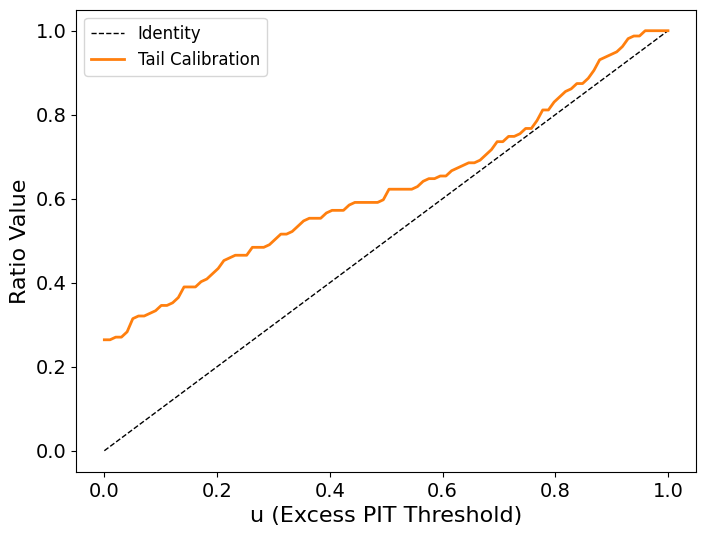

In [525]:
u_grid = np.linspace(0, 1, 100)
tail_calibration_values = [severity_ratio_func(u) for u in u_grid]
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Identity')
ax.plot(u_grid, tail_calibration_values, label='Tail Calibration', color='#FF7F0E', linewidth=2)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel('u (Excess PIT Threshold)', size=16)
ax.set_ylabel('Ratio Value', size=16)
ax.legend(fontsize=12)
plt.show()

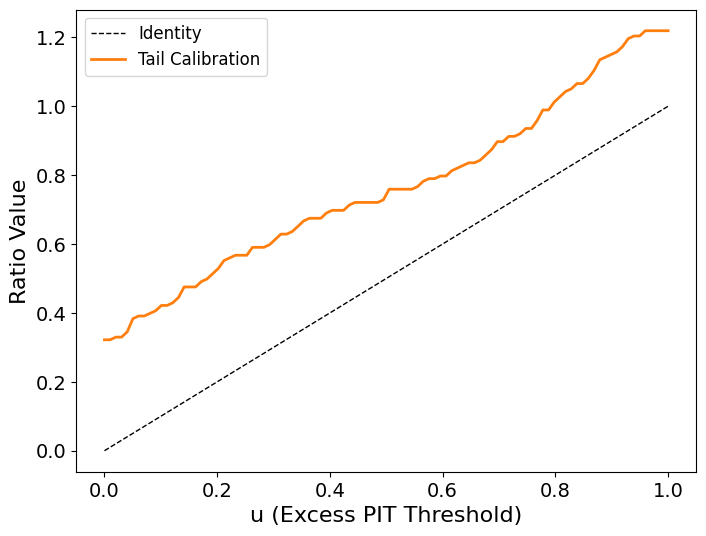

In [526]:
u_grid = np.linspace(0, 1, 100)
tail_calibration_values = [tail_calibration_func(u) for u in u_grid]
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Identity')
ax.plot(u_grid, tail_calibration_values, label='Tail Calibration', color='#FF7F0E', linewidth=2)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel('u (Excess PIT Threshold)', size=16)
ax.set_ylabel('Ratio Value', size=16)
ax.legend(fontsize=12)
plt.show()

In [530]:
mask = (result["model_id"] == "FluSight-ensemble") & (result["target"] == "wk inc flu hosp") & (result["location"] == "US") 
result[mask]

,id,reference_date,target,horizon,target_end_date,location,model_id,location_name,observation,quantile_0.01,...,quantile_0.6,quantile_0.65,quantile_0.7,quantile_0.75,quantile_0.8,quantile_0.85,quantile_0.9,quantile_0.95,quantile_0.975,quantile_0.99
209,wk inc flu hosp|2023-10-14|US|0|FluSight-ensemble,2023-10-14,wk inc flu hosp,0,2023-10-14,US,FluSight-ensemble,US,1218.0,348.084500,...,1368.726929,1392.390470,1444.980788,1519.468238,1617.958035,1758.315794,1982.348111,2342.351799,2800.969552,3216.715175
421,wk inc flu hosp|2023-10-14|US|1|FluSight-ensemble,2023-10-14,wk inc flu hosp,1,2023-10-21,US,FluSight-ensemble,US,1474.0,358.760127,...,1496.461012,1543.434500,1630.893222,1749.859485,1878.818235,2088.195957,2412.128091,3001.987528,3471.463716,4072.849690
633,wk inc flu hosp|2023-10-14|US|2|FluSight-ensemble,2023-10-14,wk inc flu hosp,2,2023-10-28,US,FluSight-ensemble,US,1610.0,373.000000,...,1709.744098,1786.802000,1889.074133,2048.409237,2202.656792,2406.747072,2736.933773,3358.213671,3954.453727,4885.374364
845,wk inc flu hosp|2023-10-14|US|3|FluSight-ensemble,2023-10-14,wk inc flu hosp,3,2023-11-04,US,FluSight-ensemble,US,1974.0,387.969000,...,1854.945000,2047.217893,2244.425377,2475.940599,2607.217027,2795.860752,3011.831097,3960.637033,4602.016340,5366.105063
1052,wk inc flu hosp|2023-10-21|US|0|FluSight-ensemble,2023-10-21,wk inc flu hosp,0,2023-10-21,US,FluSight-ensemble,US,1474.0,408.380000,...,1377.681500,1429.000000,1516.700000,1619.200000,1747.000000,1878.420000,2005.970000,2077.891602,2272.000000,2490.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44363,wk inc flu hosp|2025-05-24|US|3|FluSight-ensemble,2025-05-24,wk inc flu hosp,3,2025-06-14,US,FluSight-ensemble,US,1456.0,88.000000,...,1139.000000,1315.000000,1347.000000,1381.000000,1578.000000,1755.000000,2101.000000,2324.000000,3071.000000,3859.000000
44575,wk inc flu hosp|2025-05-31|US|0|FluSight-ensemble,2025-05-31,wk inc flu hosp,0,2025-05-31,US,FluSight-ensemble,US,1809.0,671.000000,...,1554.000000,1588.000000,1644.000000,1710.000000,1846.000000,1947.000000,2042.000000,2343.000000,2540.000000,2790.000000
44787,wk inc flu hosp|2025-05-31|US|1|FluSight-ensemble,2025-05-31,wk inc flu hosp,1,2025-06-07,US,FluSight-ensemble,US,1497.0,566.000000,...,1382.000000,1436.000000,1499.000000,1569.000000,1683.000000,1837.000000,2033.000000,2296.000000,2501.000000,3075.000000
44999,wk inc flu hosp|2025-05-31|US|2|FluSight-ensemble,2025-05-31,wk inc flu hosp,2,2025-06-14,US,FluSight-ensemble,US,1456.0,219.000000,...,1266.000000,1291.000000,1327.000000,1450.000000,1545.000000,1655.000000,2022.000000,2271.000000,2721.000000,3351.000000
